In [99]:
import typing as t
import torch
from torch.utils.data import DataLoader, Subset
from dataset import SegmentationDataset
import cv2
import matplotlib.pyplot as plt
import numpy as np
from clipseg import ClipSegProcessor
from pooler import Pooler
from segment import Segmenter
from iou import calculate_binary_iou
from tqdm import tqdm
from criteria import bottom_square
from map_diff import process_attention_maps_weighted
from PIL.Image import open as open_image


In [100]:
img_dir = '../data/examples/offroad/rellis/combined_images'
mask_dir = '../data/examples/offroad/rellis/combined_masks'

In [101]:

# ClipSegProcessor.run_model = timeit(ClipSegProcessor.run_model)

# def main(img_dir: str, mask_dir) -> None:
dataset = SegmentationDataset(img_dir, mask_dir,
                            #   transform=ToTensor(),
                            #   target_transform=ToTensor()
                            )
# Get indices for every third image
indices = list(range(0, len(dataset), 6))

# Create subset dataset
subset_dataset = Subset(dataset, indices)
dataloader = DataLoader(subset_dataset, batch_size=1, shuffle=False)



In [102]:

positive_anchors = ["grass", "gravel"]
negative_anchors = ["large bush"]
anchors = {"positive": positive_anchors, "negative": negative_anchors}
model = ClipSegProcessor(anchors)
# model_negative = ClipSegProcessor(negative_anchors)

pooler = Pooler('max')
segmenter = Segmenter('otsu')


/home/moonlab/sattwik/vision-language-mapping/ragseg/.venv/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


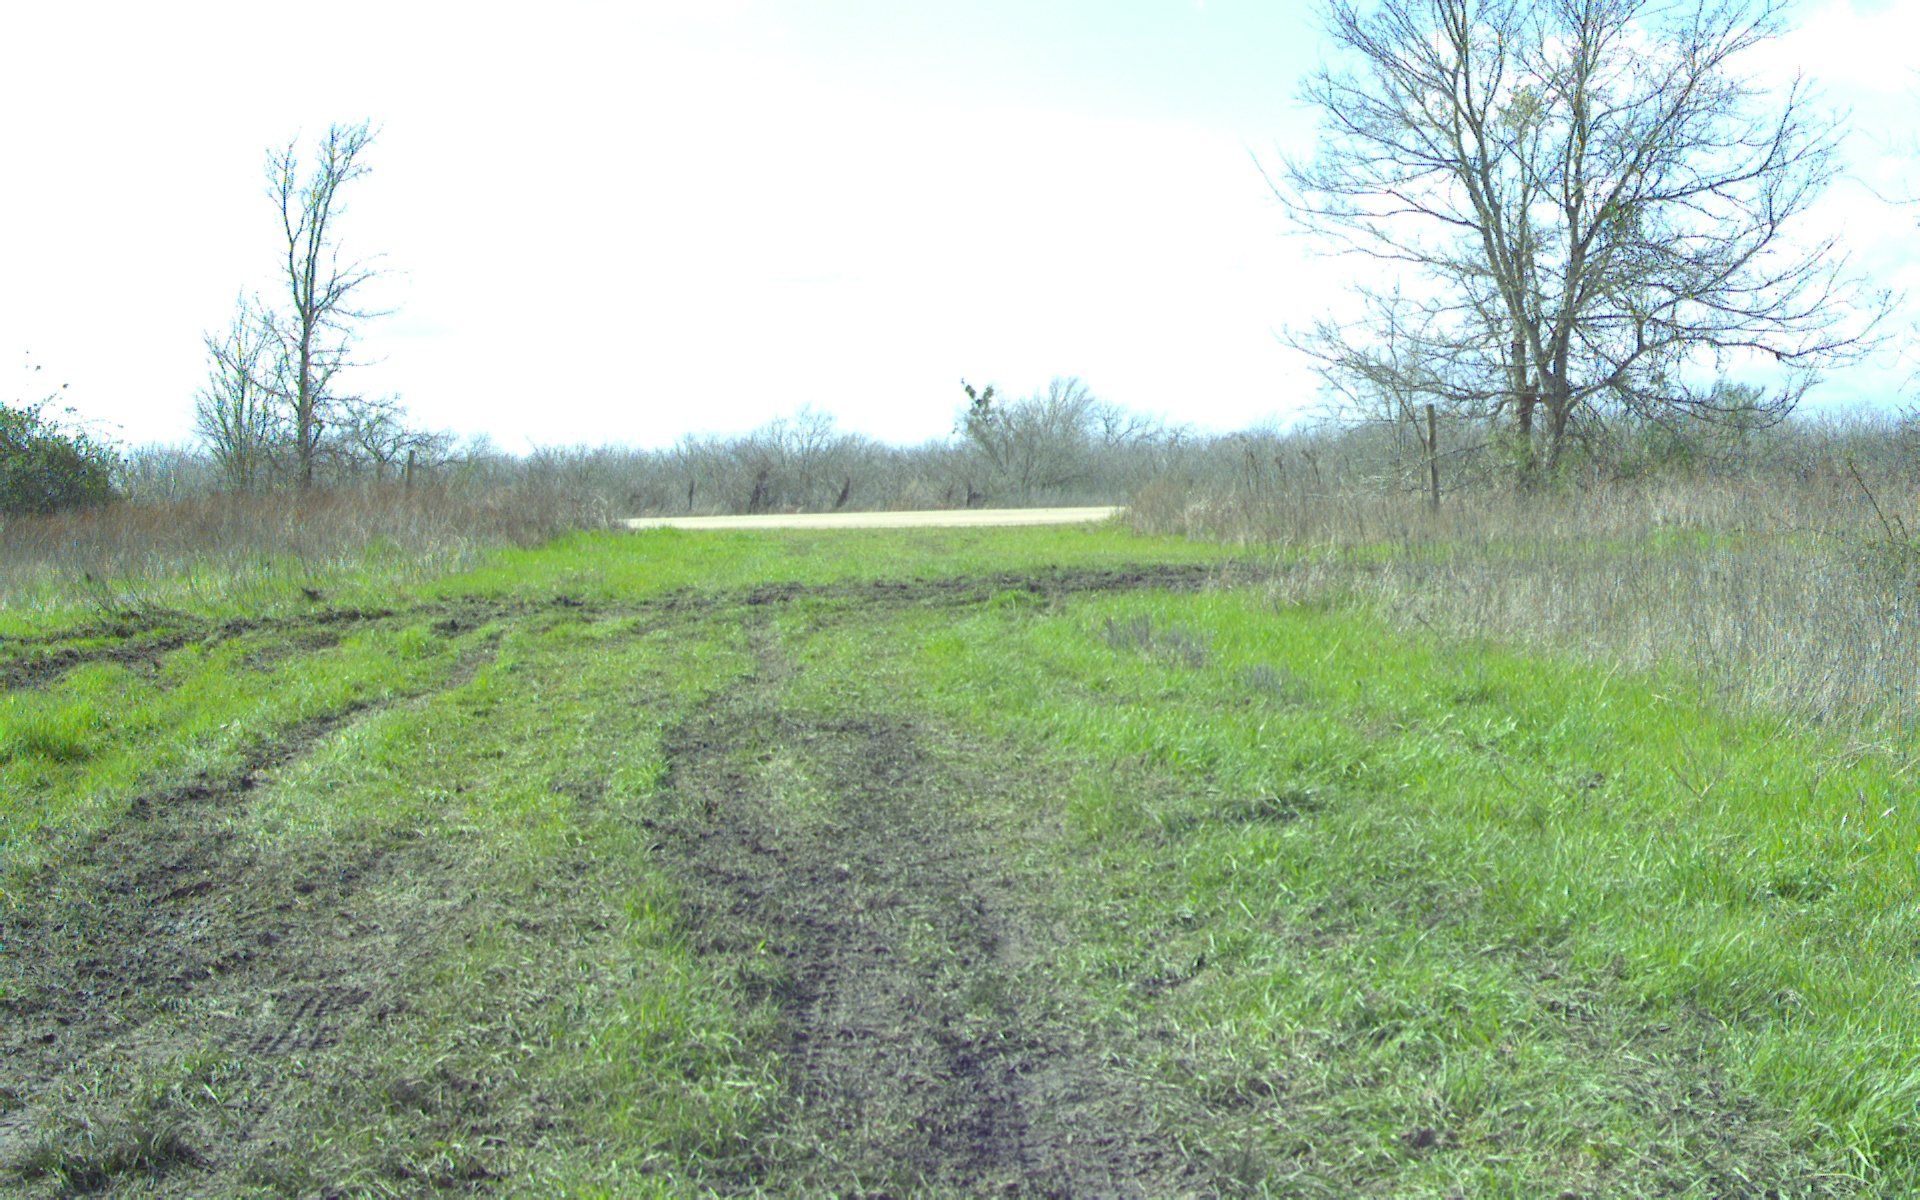

In [119]:
image_ = open_image('../data/examples/offroad/rellis/combined_images/4969.jpg')
mask_ = open_image('../data/examples/offroad/rellis/combined_masks/4969.png')
image_

In [120]:
image_ = np.array(image_)
mask_ = np.array(mask_)

In [105]:
image.shape

(1200, 1920, 3)

['grass', 'gravel', 'large bush']


/home/moonlab/sattwik/vision-language-mapping/ragseg/.venv/lib/python3.12/site-packages/transformers/image_processing_utils.py:41: UserWarning: The following named arguments are not valid for `ViTImageProcessor.preprocess` and were ignored: 'padding'
  return self.preprocess(images, **kwargs)


241.15755208333334


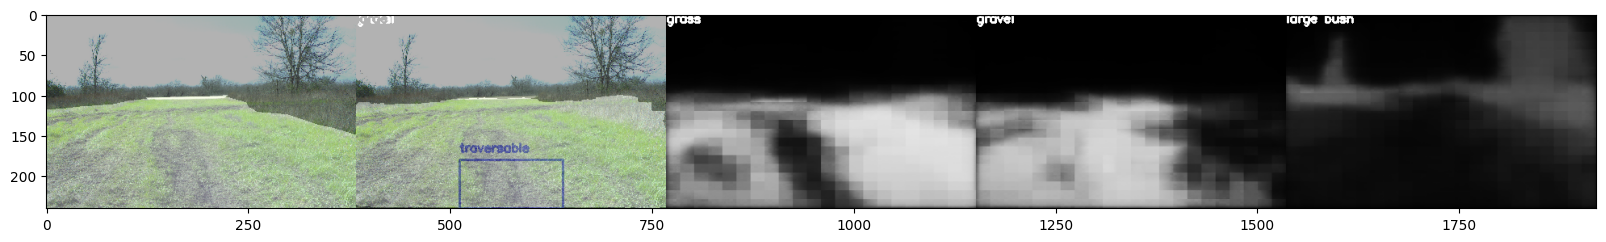

In [133]:

# image = image.permute(1, 2, 0).numpy()
image = cv2.resize(image_, (1920, image_.shape[0]*1920//image_.shape[1]))
# mask = mask.permute(1, 2, 0).numpy()
mask = cv2.resize(mask_, (1920, mask_.shape[0]*1920//mask_.shape[1]))
mask = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)

maps: t.List[np.ndarray] = model.run_model(image_)
# negative_maps: t.List[np.ndarray] = model_negative.run_model(image)

positive_maps = maps[:len(model.prompts['positive'])]
negative_maps = maps[len(model.prompts['positive']):]

positive_pooled_map = pooler.pool(np.array(positive_maps))
negative_pooled_map = pooler.pool(np.array(negative_maps))

pooled_map = process_attention_maps_weighted(positive_pooled_map, negative_pooled_map, 1.5, 1)

segmented_map = segmenter.segment(pooled_map)

traversable, centre_cell_coords, cell_score = bottom_square(pooled_map, 75)
start_row, end_row, start_col, end_col = centre_cell_coords

# Draw the bottom center cell on the segmented map
pooled_map = cv2.rectangle(pooled_map, (start_col, start_row), (end_col, end_row), (0, 0, 255), 2)
label_pooled = "traversable_pooled" if traversable else "non-traversable_pooled | Please Enter new prompt"
#label rectangle
pooled_map = cv2.putText(pooled_map, f"{label_pooled}", (start_col, start_row-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

# Draw the bottom center cell on the segmented map
segmented_map = cv2.rectangle(segmented_map, (start_col, start_row), (end_col, end_row), (0, 0, 255), 2)
label = "traversable" if traversable else "non-traversable | Please Enter new prompt"
#label rectangle
segmented_map = cv2.putText(segmented_map, f"{label}", (start_col, start_row-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

image = cv2.resize(image, (image.shape[1]//(len(maps)+2), image.shape[0]//(len(maps)+2)))
mask = cv2.resize(mask, (mask.shape[1]//(len(maps)+2), mask.shape[0]//(len(maps)+2)))
superimposed = cv2.addWeighted(image, 0.7, mask, 0.3, 0)
# print(f"image shape: {image.shape}, mask shape: {mask.shape}, pooled_map shape: {pooled_map.shape}, segmented_map shape: {segmented_map.shape}")
superimposed_map = cv2.addWeighted(image, 0.7, segmented_map, 0.3, 0)

output = [superimposed, superimposed_map] + maps
output = cv2.hconcat(output)
print(cell_score)
 #show large figure
plt.figure(figsize=(20, 10))
plt.imshow(output)

In [134]:
bottom_square(positive_pooled_map, 75)

(np.True_, (180, 240, 128, 256), np.float64(190.71770833333332))

In [135]:
bottom_square(negative_pooled_map, 75)

(np.False_, (180, 240, 128, 256), np.float64(9.322916666666666))

In [132]:
len(maps)

3

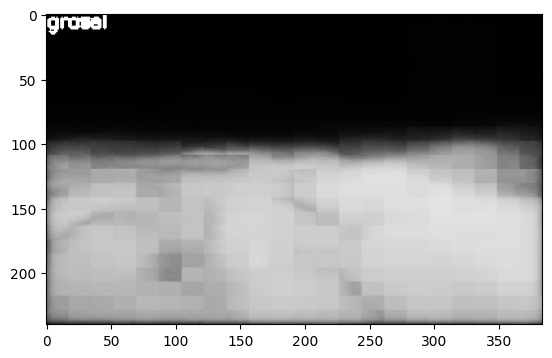

In [109]:
plt.imshow(positive_pooled_map)

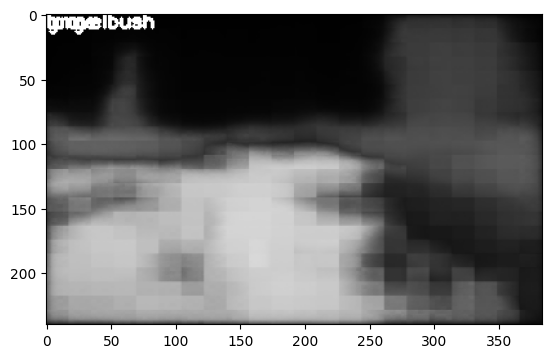

In [110]:
plt.imshow(negative_pooled_map)

In [111]:
def process_attention_maps(go_to_map, avoid_map):
    # Normalize both maps to 0-1 range
    go_to_norm = go_to_map.astype(float) / 255
    avoid_norm = avoid_map.astype(float) / 255

    # Invert the avoid map
    avoid_inverted = 1 - avoid_norm

    # Multiply go_to map with inverted avoid map
    result = go_to_norm * avoid_inverted

    # Scale back to 0-255 range and convert to uint8
    result_uint8 = (result * 255).astype(np.uint8)

    return result_uint8

In [112]:
pooled_map = process_attention_maps(positive_pooled_map, negative_pooled_map)

(array([9.4299e+04, 7.5180e+03, 1.8450e+03, 2.1720e+03, 1.1970e+03,
        1.4880e+03, 8.2500e+02, 1.1880e+03, 5.9400e+02, 8.6100e+02,
        7.6500e+02, 5.4600e+02, 1.3740e+03, 2.7720e+03, 6.7590e+03,
        5.4900e+03, 1.0995e+04, 7.0710e+03, 9.2280e+03, 4.6260e+03,
        1.0692e+04, 9.0690e+03, 4.7340e+03, 6.3060e+03, 6.2640e+03,
        2.0760e+03, 1.4760e+03, 2.0250e+03, 1.2480e+03, 1.7130e+03,
        1.9530e+03, 9.8400e+02, 1.6350e+03, 1.2300e+03, 1.6590e+03,
        9.6000e+02, 1.5510e+03, 1.0770e+03, 2.2680e+03, 1.5090e+03,
        1.8630e+03, 1.6530e+03, 9.6000e+02, 1.2840e+03, 1.0770e+03,
        1.4250e+03, 1.1520e+03, 1.6950e+03, 6.8700e+02, 1.6860e+03,
        1.0830e+03, 6.8100e+02, 1.3440e+03, 1.0770e+03, 1.1640e+03,
        8.0100e+02, 1.3500e+03, 7.2300e+02, 9.3300e+02, 7.1700e+02,
        1.4580e+03, 1.0830e+03, 8.6700e+02, 1.3860e+03, 8.2500e+02,
        1.4430e+03, 1.2840e+03, 1.5750e+03, 9.3600e+02, 2.1990e+03,
        1.8000e+03, 1.2900e+03, 1.6770e+03, 1.87

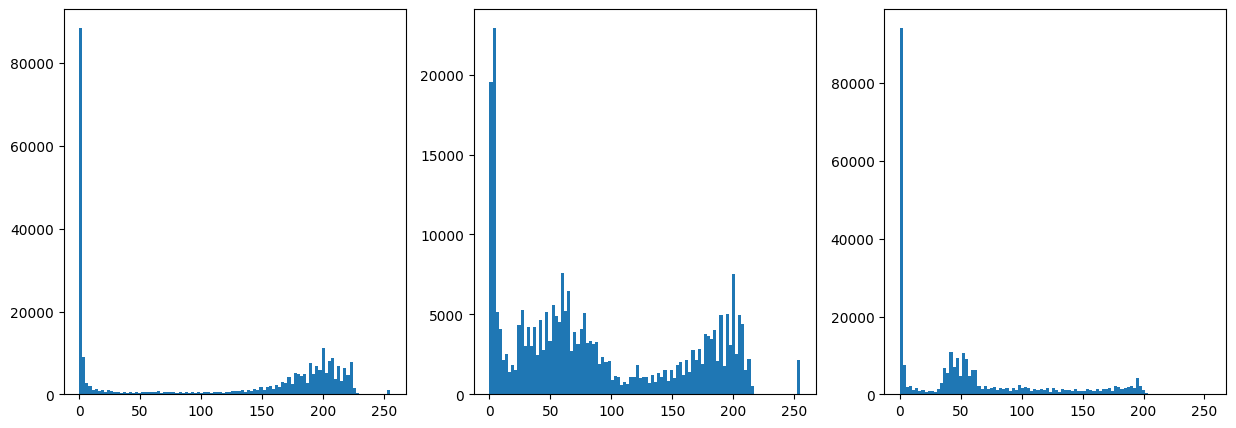

In [113]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].hist(positive_pooled_map.flatten(), bins=100)
ax[1].hist(negative_pooled_map.flatten(), bins=100)
ax[2].hist(pooled_map.flatten(), bins=100)

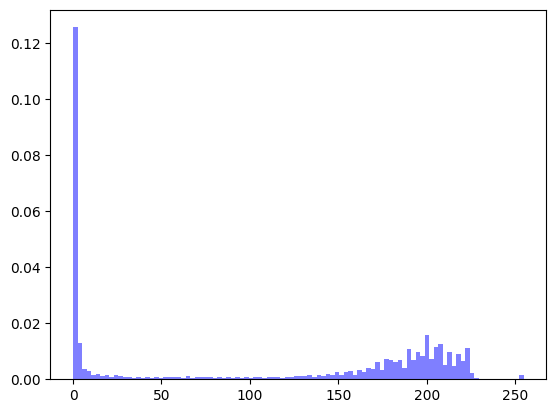

In [114]:
n, bins, patches = plt.hist(positive_pooled_map.flatten(), bins=100, range=(0, 255), density=True, alpha=0.5, color='b')

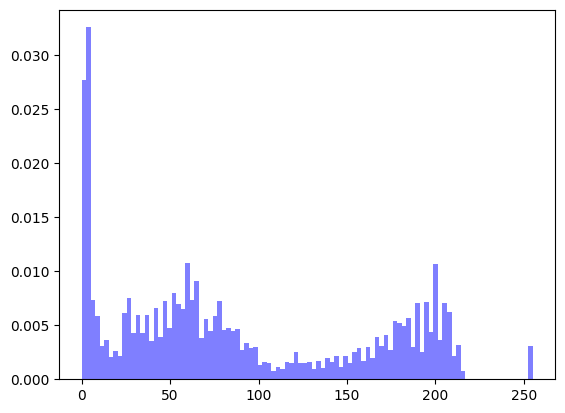

In [115]:
n, bins, patches = plt.hist(negative_pooled_map.flatten(), bins=100, range=(0, 255), density=True, alpha=0.5, color='b')

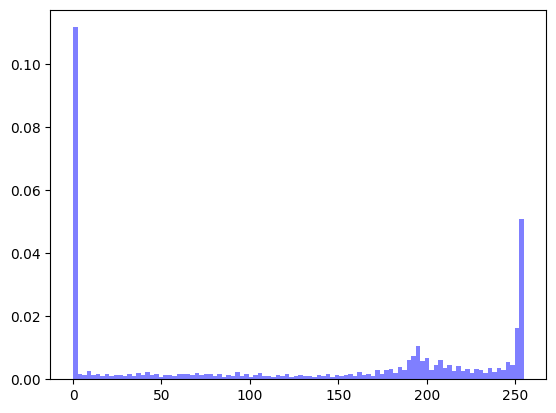

In [116]:
n, bins, patches = plt.hist((positive_pooled_map-negative_pooled_map).flatten(), bins=100, range=(0, 255), density=True, alpha=0.5, color='b')